In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Forma del DataFrame: (9564, 50)

Tipos de datos por columna:
 rowid                  int64
kepid                  int64
kepoi_name            object
kepler_name           object
koi_disposition       object
koi_pdisposition      object
koi_score            float64
koi_fpflag_nt          int64
koi_fpflag_ss          int64
koi_fpflag_co          int64
koi_fpflag_ec          int64
koi_period           float64
koi_period_err1      float64
koi_period_err2      float64
koi_time0bk          float64
koi_time0bk_err1     float64
koi_time0bk_err2     float64
koi_impact           float64
koi_impact_err1      float64
koi_impact_err2      float64
koi_duration         float64
koi_duration_err1    float64
koi_duration_err2    float64
koi_depth            float64
koi_depth_err1       float64
koi_depth_err2       float64
koi_prad             float64
koi_prad_err1        float64
koi_prad_err2        float64
koi_teq              float64
koi_teq_err1         float64
koi_teq_err2         float64
koi_insol 

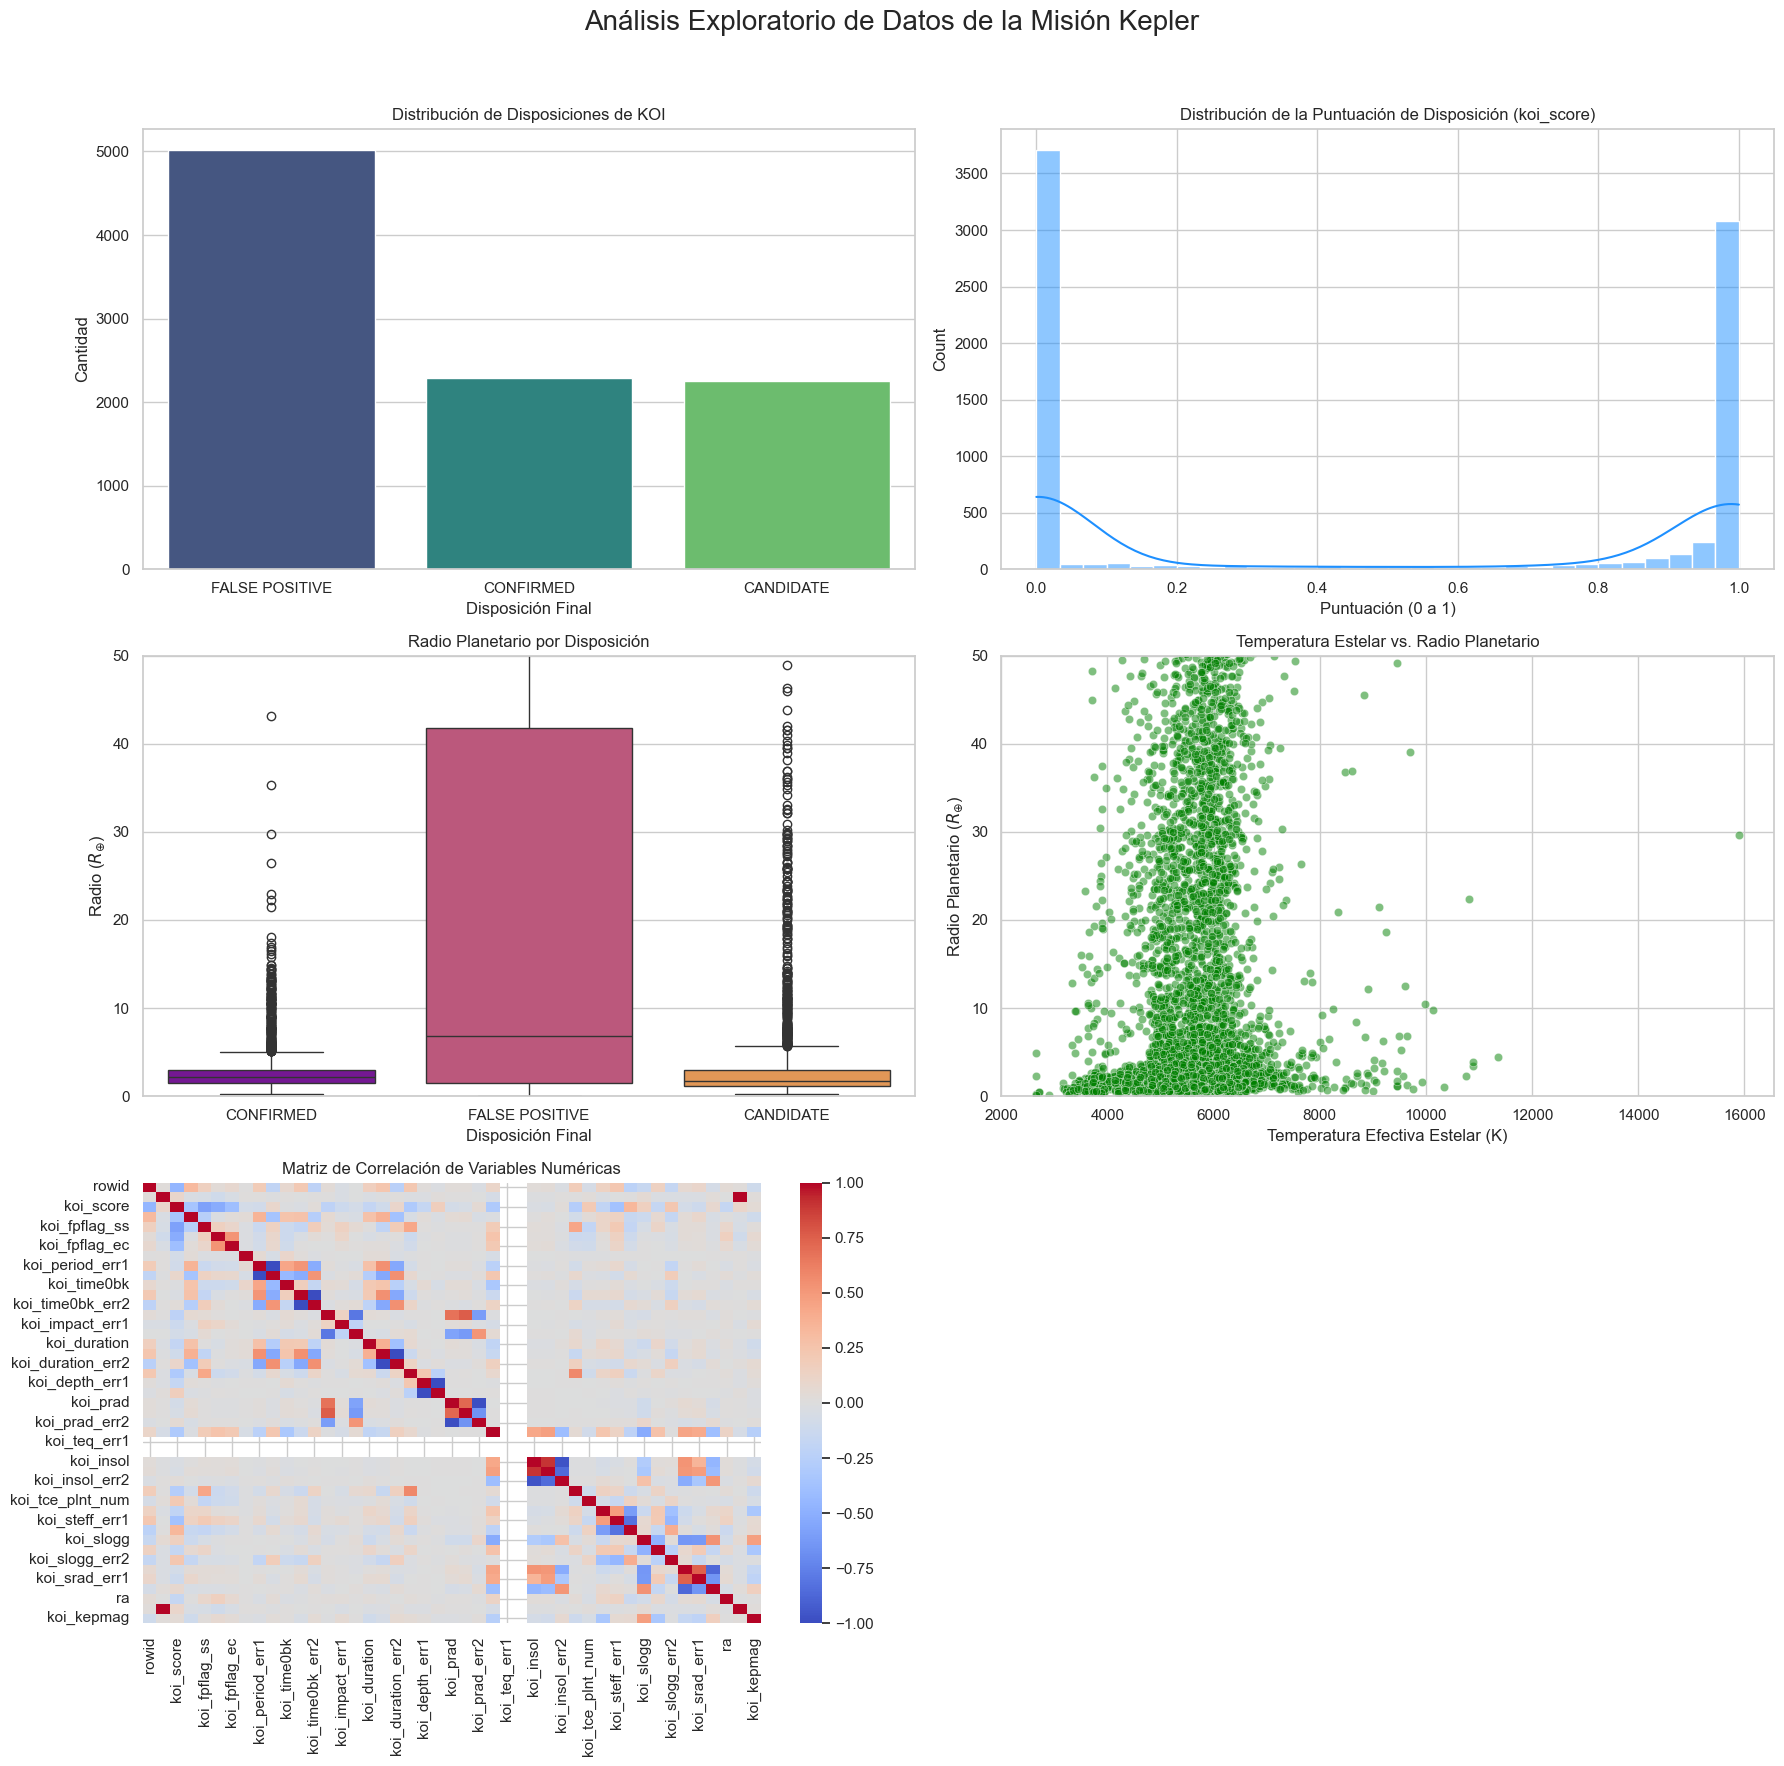

In [62]:
# =============================
# 0. Importación de Librerías
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Cargar el archivo CSV
try:
    df = pd.read_csv("cumulative (2).csv")
except FileNotFoundError:
    print("Error: El archivo 'cumulative (2).csv' no se encontró en el directorio.")
    exit()

# =============================
# 1. Información general
# =============================
print("Forma del DataFrame:", df.shape)
print("\nTipos de datos por columna:\n", df.dtypes)
print("\nPorcentaje de valores nulos:\n", df.isnull().mean().sort_values(ascending=False) * 100)
print("\nEstadísticas descriptivas:\n", df.describe())

# =============================
# 2. Análisis categórico
# =============================
print("\nDistribución de 'koi_disposition':\n", df['koi_disposition'].value_counts())
print("\nDistribución de 'koi_pdisposition':\n", df['koi_pdisposition'].value_counts())

# =============================
# 3. Visualizaciones
# =============================

# Preparar datos
disposition_counts = df['koi_disposition'].value_counts()
score_data = df['koi_score'].dropna()
prad_disposition = df[['koi_prad', 'koi_disposition']].dropna()
scatter_data = df[['koi_steff', 'koi_prad']].dropna()

numeric_cols = df.select_dtypes(include='number')
correlation_matrix = numeric_cols.corr()

# Crear subplots
fig, axs = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Análisis Exploratorio de Datos de la Misión Kepler', fontsize=20)

# Gráfico 1: Distribución de disposiciones
# CORREGIDO para evitar FutureWarning
sns.barplot(x=disposition_counts.index, y=disposition_counts.values, ax=axs[0, 0], palette='viridis', hue=disposition_counts.index, legend=False)
axs[0, 0].set_title("Distribución de Disposiciones de KOI")
axs[0, 0].set_ylabel("Cantidad")
axs[0, 0].set_xlabel("Disposición Final")

# Gráfico 2: Histograma de koi_score
sns.histplot(score_data, bins=30, kde=True, ax=axs[0, 1], color='dodgerblue')
axs[0, 1].set_title("Distribución de la Puntuación de Disposición (koi_score)")
axs[0, 1].set_xlabel("Puntuación (0 a 1)")

# Gráfico 3: Boxplot de radio planetario por disposición
# CORREGIDO para evitar FutureWarning
sns.boxplot(x='koi_disposition', y='koi_prad', data=prad_disposition, ax=axs[1, 0], palette='plasma', hue='koi_disposition', legend=False)
axs[1, 0].set_title("Radio Planetario por Disposición")
axs[1, 0].set_ylabel(r"Radio ($R_{\oplus}$)")
axs[1, 0].set_xlabel("Disposición Final")
axs[1, 0].set_ylim(0, 50) 

# Gráfico 4: Scatterplot de temperatura estelar vs radio planetario
sns.scatterplot(x='koi_steff', y='koi_prad', data=scatter_data, ax=axs[1, 1], alpha=0.5, color='green')
axs[1, 1].set_title("Temperatura Estelar vs. Radio Planetario")
axs[1, 1].set_xlabel("Temperatura Efectiva Estelar (K)")
axs[1, 1].set_ylabel(r"Radio Planetario ($R_{\oplus}$)")
axs[1, 1].set_ylim(0, 50)

# Gráfico 5: Mapa de calor de correlaciones
sns.heatmap(correlation_matrix, cmap="coolwarm", ax=axs[2, 0], cbar=True)
axs[2, 0].set_title("Matriz de Correlación de Variables Numéricas")

# Quitar el subplot vacío que queda
fig.delaxes(axs[2, 1])

# Ajustar el layout para evitar que los títulos se solapen y mostrar el gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [63]:
pip install pandas numpy matplotlib seaborn scikit-learn shap xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
"""
=============================================================================
ANÁLISIS DE EXOPLANETAS KEPLER CON MACHINE LEARNING
Servicio Social: Clasificación usando Árboles de Decisión y Random Forest
Autor: [Tu nombre]
Fecha: 2025
=============================================================================
"""

'\n=============================================================================\nANÁLISIS DE EXOPLANETAS KEPLER CON MACHINE LEARNING\nServicio Social: Clasificación usando Árboles de Decisión y Random Forest\nAutor: [Tu nombre]\nFecha: 2025\n=============================================================================\n'

In [65]:
# 0. IMPORTACIÓN DE LIBRERÍAS
print("=" * 80)
print("INICIANDO ANÁLISIS DE EXOPLANETAS KEPLER")
print("=" * 80)
print("\n Cargando librerías...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos principales para tu servicio
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Modelos adicionales para comparación
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
# xgboost / lightgbm son opcionales, estén instalados en tu entorno
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef
)

# Configuración
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10
print("Librerías cargadas exitosamente.")

# =============================================================================
# 1. FUNCIONES AUXILIARES
# =============================================================================

def print_section(title):
    """Imprime un separador de sección formateado"""
    print(f"\n{'='*80}")
    print(f" {title}")
    print('='*80)

def analyze_class_distribution(y, title="Distribución de Clases"):
    """Analiza y visualiza la distribución de clases"""
    class_counts = y.value_counts().sort_index()
    class_percentages = y.value_counts(normalize=True).sort_index() * 100

    print(f"\n{title}:")
    print("-" * 40)
    label_map = {0: 'FALSE POSITIVE', 1: 'CONFIRMED', 2: 'CANDIDATE'}
    for class_name, count in class_counts.items():
        percentage = class_percentages.loc[class_name]
        label = label_map.get(class_name, str(class_name))
        print(f"{label}: {count:,} ({percentage:.2f}%)")

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    ax1.bar(range(len(class_counts)), class_counts.values, color=colors[:len(class_counts)])
    ax1.set_xticks(range(len(class_counts)))
    ax1.set_xticklabels([label_map.get(i, str(i)) for i in class_counts.index])
    ax1.set_ylabel('Cantidad')
    ax1.set_title('Distribución de Clases - Conteo')
    ax1.grid(axis='y', alpha=0.3)

    # Gráfico de pastel
    ax2.pie(class_counts.values, labels=[label_map.get(i, str(i)) for i in class_counts.index],
            autopct='%1.1f%%', colors=colors[:len(class_counts)], startangle=90)
    ax2.set_title('Distribución de Clases - Porcentaje')

    plt.tight_layout()
    plt.show()

    return class_counts

def feature_importance_analysis(model, feature_names, top_n=15):
    """Analiza y visualiza la importancia de características"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        if len(importances) != len(feature_names):
            # seguridad: si tamaños no coinciden, crear DataFrame defensivo
            feature_names = list(feature_names)[:len(importances)]
        indices = np.argsort(importances)[::-1][:top_n]

        plt.figure(figsize=(12, 6))
        plt.title(f'Top {top_n} Características Más Importantes')
        plt.bar(range(len(indices)), importances[indices], color='steelblue')
        plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.ylabel('Importancia')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        return pd.DataFrame({
            'Feature': [feature_names[i] for i in indices],
            'Importance': importances[indices]
        })
    else:
        print(" El modelo no tiene atributo 'feature_importances_'.")
        return None

def plot_learning_curves(model, X, y, cv=5, title="Curvas de Aprendizaje"):
    """Genera curvas de aprendizaje para evaluar overfitting/underfitting"""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', label='Entrenamiento')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.plot(train_sizes, val_mean, 'o-', label='Validación')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)

    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()


INICIANDO ANÁLISIS DE EXOPLANETAS KEPLER

 Cargando librerías...
Librerías cargadas exitosamente.


In [66]:
# 2. CARGA Y EXPLORACIÓN INICIAL DE DATOS
# =============================================================================
print_section("CARGA Y EXPLORACIÓN DE DATOS")

try:
    df = pd.read_csv("cumulative (2).csv")
    print(f" Archivo CSV cargado exitosamente.")
    print(f" Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

    # Información básica del dataset
    print(f"\n Información básica del dataset:")
    print(f"  - Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  - Tipos de datos únicos: {df.dtypes.nunique()}")
    print(f"  - Columnas numéricas: {df.select_dtypes(include=np.number).shape[1]}")
    print(f"  - Columnas categóricas: {df.select_dtypes(include='object').shape[1]}")

except FileNotFoundError:
    print(" Error: El archivo 'cumulative (2).csv' no se encontró.")
    raise



 CARGA Y EXPLORACIÓN DE DATOS
 Archivo CSV cargado exitosamente.
 Dimensiones del dataset: 9,564 filas × 50 columnas

 Información básica del dataset:
  - Memoria utilizada: 5.84 MB
  - Tipos de datos únicos: 3
  - Columnas numéricas: 45
  - Columnas categóricas: 5



 LIMPIEZA Y PREPARACIÓN DE DATOS
✓ Eliminadas columnas de metadatos (si existían)
✓ Eliminadas columnas no físicas (si existían)
✓ Eliminadas 2 columnas con >50% valores nulos

 Dataset final:
  - Características: 34
  - Observaciones: 9,564
  - Clases: 3

Distribución de Clases en Dataset Completo:
----------------------------------------
FALSE POSITIVE: 5,023 (52.52%)
CONFIRMED: 2,293 (23.98%)
CANDIDATE: 2,248 (23.50%)


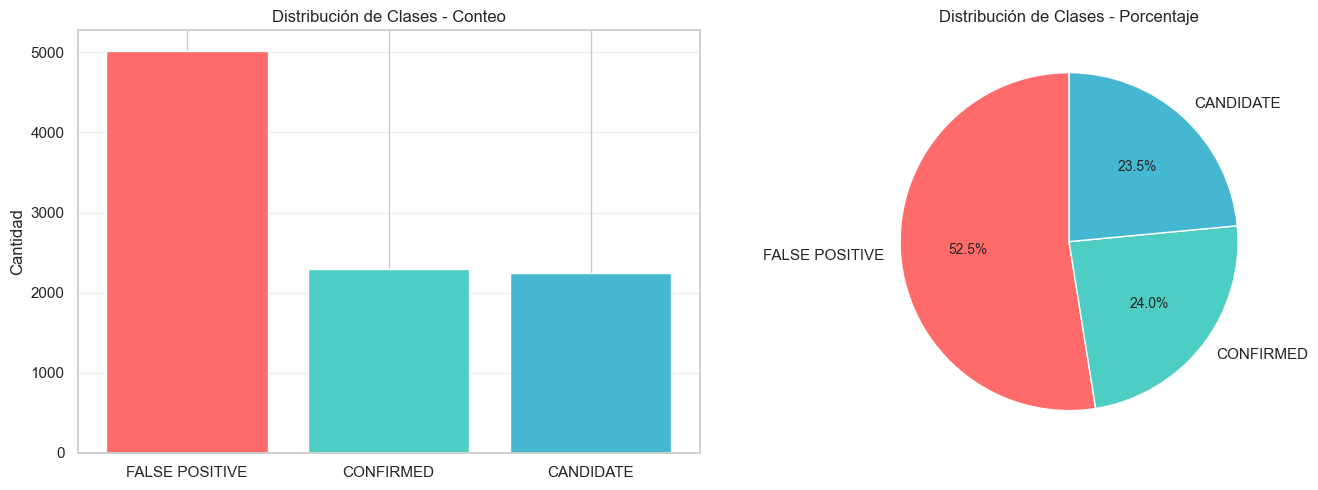


✓ División de datos:
  - Entrenamiento: 6,694 (70.0%)
  - Prueba: 2,870 (30.0%)


In [67]:
# 3. LIMPIEZA Y PREPARACIÓN DE DATOS
# =============================================================================
print_section("LIMPIEZA Y PREPARACIÓN DE DATOS")

# Columnas a eliminar (metadatos e identificadores)
cols_to_drop_initial = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition',
    'koi_tce_delivname', 'koi_score'
]
df_cleaned = df.drop(columns=cols_to_drop_initial, errors='ignore')
df_cleaned = df_cleaned.dropna(subset=['koi_disposition'])
print(f"✓ Eliminadas columnas de metadatos (si existían)")

# Eliminar columnas no físicas (flags y métricas estadísticas)
cols_to_drop_non_physical = [
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_model_snr', 'koi_tce_plnt_num'
]
df_cleaned = df_cleaned.drop(columns=cols_to_drop_non_physical, errors='ignore')
print(f"✓ Eliminadas columnas no físicas (si existían)")

# Manejo de valores infinitos
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)

# Mapeo de la variable objetivo
disposition_mapping = {'CONFIRMED': 1, 'FALSE POSITIVE': 0, 'CANDIDATE': 2}
df_cleaned['koi_disposition'] = df_cleaned['koi_disposition'].map(disposition_mapping)
target_names = ['FALSE POSITIVE', 'CONFIRMED', 'CANDIDATE']

# Análisis de valores faltantes
missing_fractions = df_cleaned.isnull().mean()
cols_to_drop_missing = missing_fractions[missing_fractions > 0.5].index.tolist()
df_cleaned = df_cleaned.drop(columns=cols_to_drop_missing)
print(f"✓ Eliminadas {len(cols_to_drop_missing)} columnas con >50% valores nulos")

# Preparación de características y objetivo
X = df_cleaned.drop('koi_disposition', axis=1).select_dtypes(include=np.number)
y = df_cleaned['koi_disposition']
feature_names = X.columns.tolist()

print(f"\n Dataset final:")
print(f"  - Características: {X.shape[1]}")
print(f"  - Observaciones: {X.shape[0]:,}")
print(f"  - Clases: {len(y.unique())}")

# Análisis de distribución de clases
class_distribution = analyze_class_distribution(y, "Distribución de Clases en Dataset Completo")

# División de datos con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\n✓ División de datos:")
print(f"  - Entrenamiento: {X_train.shape[0]:,} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"  - Prueba: {X_test.shape[0]:,} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")


In [68]:
# 4. PIPELINE DE PREPROCESAMIENTO OPTIMIZADO
# =============================================================================
print_section("PIPELINE DE PREPROCESAMIENTO")

# Determinar número óptimo de características
k_features = min(30, len(feature_names))
if k_features < 1:
    raise ValueError("No hay características numéricas disponibles para entrenar.")

# Pipeline con selección de características basada en información mutua
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(mutual_info_classif, k=k_features)),
    ('scaler', StandardScaler())
])

# Aplicar pipeline
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# Obtener características seleccionadas
selected_mask = preprocessing_pipeline.named_steps['selector'].get_support()
selected_features = [f for f, m in zip(feature_names, selected_mask) if m]

print(f"✓ Pipeline aplicado:")
print(f"  - Características originales: {len(feature_names)}")
print(f"  - Características seleccionadas: {len(selected_features)}")
print(f"\n Top 10 características seleccionadas:")

# Algunos SelectKBest (con mutual_info) no exponen 'scores_' cuando se usa en ciertas versiones;
# por seguridad comprobamos su existencia
selector_scores = getattr(preprocessing_pipeline.named_steps['selector'], 'scores_', None)
if selector_scores is not None:
    sel_scores = selector_scores[selected_mask]
    top_df = pd.DataFrame({
        'Feature': selected_features,
        'Score': sel_scores
    }).sort_values('Score', ascending=False).head(10)
    print(top_df.to_string(index=False))
else:
    print("El selector no expone 'scores_'. Mostrar solo nombres de features:")
    print(selected_features[:10])


 PIPELINE DE PREPROCESAMIENTO
✓ Pipeline aplicado:
  - Características originales: 34
  - Características seleccionadas: 30

 Top 10 características seleccionadas:
          Feature    Score
         koi_prad 0.166052
koi_duration_err2 0.162378
koi_duration_err1 0.155907
    koi_prad_err1 0.154909
    koi_prad_err2 0.139350
   koi_steff_err1 0.137852
   koi_steff_err2 0.134019
 koi_time0bk_err2 0.129184
 koi_time0bk_err1 0.126176
       koi_period 0.123496


In [69]:
# 5. OPTIMIZACIÓN DE HIPERPARÁMETROS PARA MODELOS PRINCIPALES
# =============================================================================
print_section("OPTIMIZACIÓN DE HIPERPARÁMETROS")

# Configuración de validación cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5.1 Optimización de Árbol de Decisión
print("\n Optimizando Árbol de Decisión...")
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train_processed, y_train)
best_dt = dt_grid.best_estimator_
print(f" Mejores parámetros DT: {dt_grid.best_params_}")
print(f" Mejor score CV (F1-weighted): {dt_grid.best_score_:.4f}")

# 5.2 Optimización de Random Forest
print("\n Optimizando Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_processed, y_train)
best_rf = rf_grid.best_estimator_
print(f" Mejores parámetros RF: {rf_grid.best_params_}")
print(f" Mejor score CV (F1-weighted): {rf_grid.best_score_:.4f}")


 OPTIMIZACIÓN DE HIPERPARÁMETROS

 Optimizando Árbol de Decisión...
 Mejores parámetros DT: {'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
 Mejor score CV (F1-weighted): 0.7191

 Optimizando Random Forest...
 Mejores parámetros RF: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
 Mejor score CV (F1-weighted): 0.7459



 EVALUACIÓN COMPLETA DE MODELOS

 Evaluando: Decision Tree (Optimizado)
  Accuracy (CV): 0.7169 ± 0.0084
  Accuracy (Test): 0.7157
  F1-Score: 0.7172

 Evaluando: Random Forest (Optimizado)
  Accuracy (CV): 0.7586 ± 0.0068
  Accuracy (Test): 0.7578
  F1-Score: 0.7420

 Evaluando: Decision Tree (Default)
  Accuracy (CV): 0.6640 ± 0.0109
  Accuracy (Test): 0.6672
  F1-Score: 0.6690

 Evaluando: Random Forest (Default)
  Accuracy (CV): 0.7528 ± 0.0041
  Accuracy (Test): 0.7530
  F1-Score: 0.7384

 Evaluando: XGBoost
  Accuracy (CV): 0.7595 ± 0.0099
  Accuracy (Test): 0.7613
  F1-Score: 0.7516

 Evaluando: LightGBM
  Accuracy (CV): 0.7723 ± 0.0059
  Accuracy (Test): 0.7603
  F1-Score: 0.7487

 Evaluando: AdaBoost con DT
  Accuracy (CV): 0.7323 ± 0.0036
  Accuracy (Test): 0.7411
  F1-Score: 0.7328

 Evaluando: Logistic Regression
  Accuracy (CV): 0.7011 ± 0.0064
  Accuracy (Test): 0.7014
  F1-Score: 0.6606

 Evaluando: Neural Network
  Accuracy (CV): 0.7256 ± 0.0119
  Accuracy (Test): 0.72

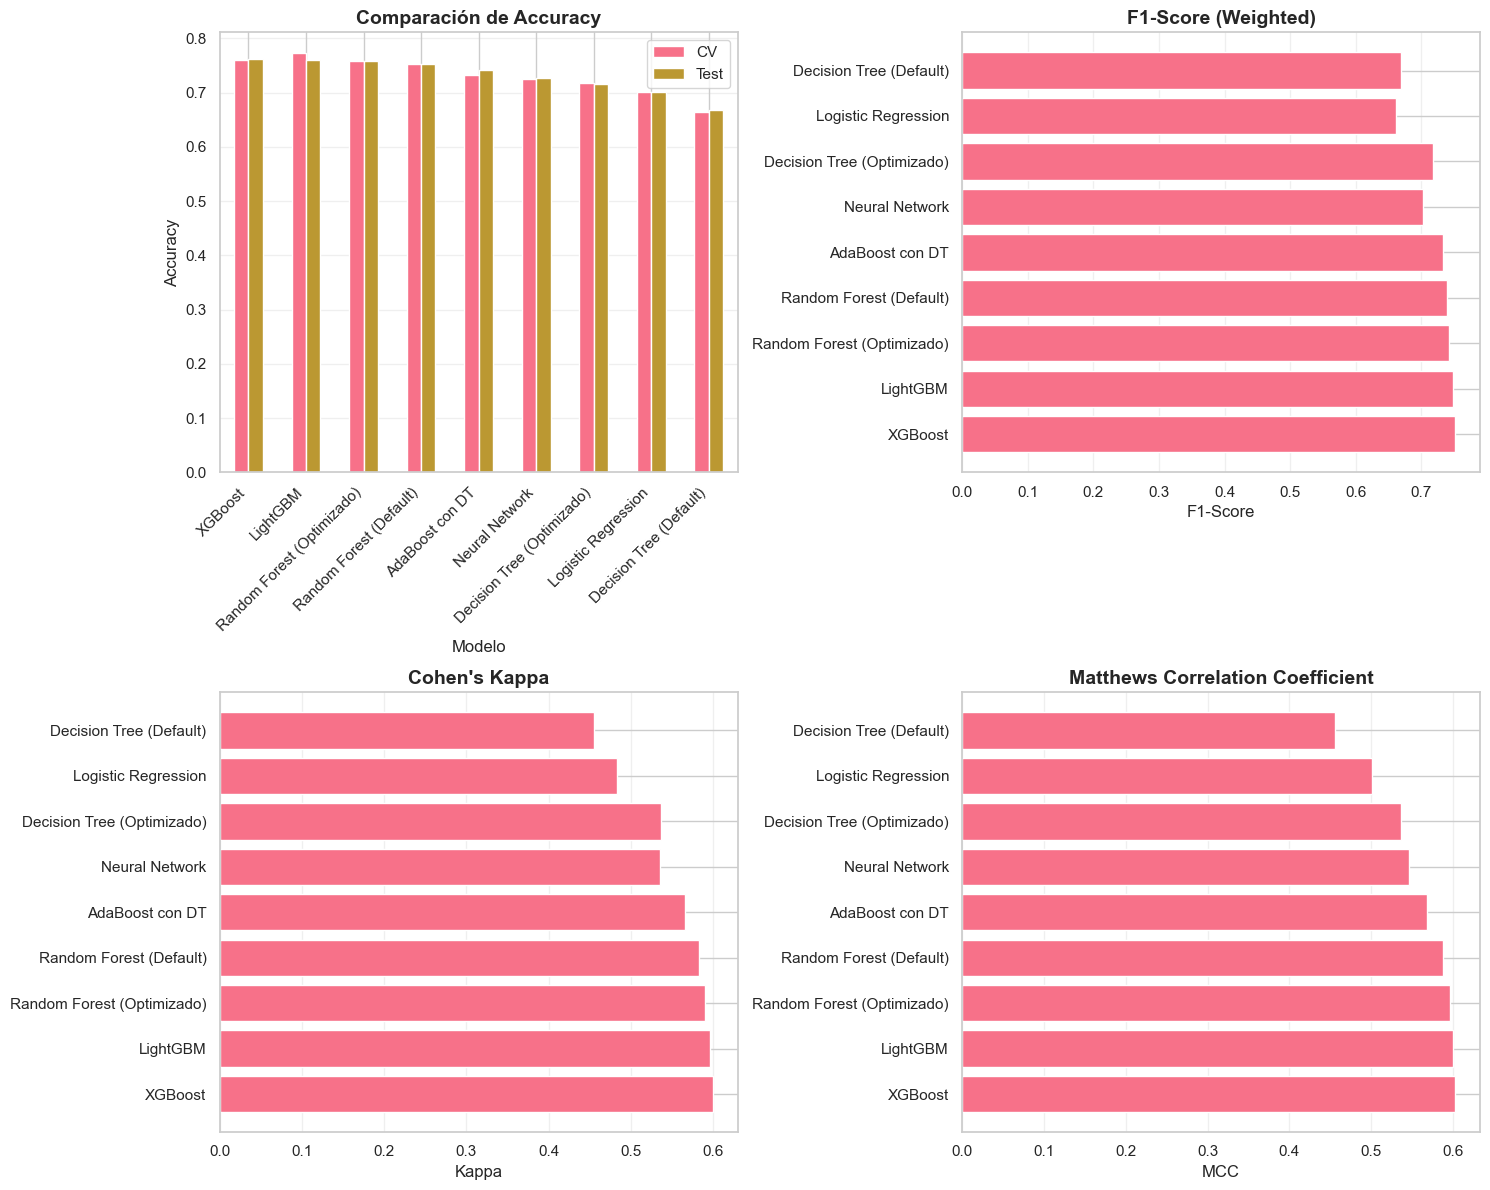

In [70]:
# 6. EVALUACIÓN COMPLETA DE MODELOS
# =============================================================================
print_section("EVALUACIÓN COMPLETA DE MODELOS")

# Definir todos los modelos a evaluar (omitimos XGBoost/LightGBM si no están instalados)
models = {
    "Decision Tree (Optimizado)": best_dt,
    "Random Forest (Optimizado)": best_rf,
    "Decision Tree (Default)": DecisionTreeClassifier(random_state=42),
    "Random Forest (Default)": RandomForestClassifier(random_state=42, n_jobs=-1),
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(random_state=42, verbose=-1)

models.update({
    "AdaBoost con DT": AdaBoostClassifier(DecisionTreeClassifier(max_depth=3), n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)
})

results = []
detailed_results = {}

for name, model in models.items():
    print(f"\n Evaluando: {name}")

    # Validación cruzada
    try:
        cv_scores = cross_val_score(model, X_train_processed, y_train,
                                    cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    except Exception as e:
        print(f"CV falló para {name}: {e}")
        cv_scores = np.array([np.nan])

    # Entrenamiento y predicción
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_pred_proba = model.predict_proba(X_test_processed) if hasattr(model, 'predict_proba') else None

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'Modelo': name,
        'Accuracy (CV)': np.nanmean(cv_scores),
        'Std (CV)': np.nanstd(cv_scores),
        'Accuracy (Test)': accuracy,
        'F1-Score (Weighted)': f1_weighted,
        'Kappa': kappa,
        'MCC': mcc
    })

    detailed_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'cv_scores': cv_scores
    }

    print(f"  Accuracy (CV): {np.nanmean(cv_scores):.4f} ± {np.nanstd(cv_scores):.4f}")
    print(f"  Accuracy (Test): {accuracy:.4f}")
    print(f"  F1-Score: {f1_weighted:.4f}")

# Crear DataFrame de resultados
results_df = pd.DataFrame(results).sort_values('Accuracy (Test)', ascending=False)
print("\n" + "="*80)
print("TABLA COMPARATIVA DE RENDIMIENTO")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Accuracy
ax1 = axes[0, 0]
results_df.plot(x='Modelo', y=['Accuracy (CV)', 'Accuracy (Test)'],
                kind='bar', ax=ax1)
ax1.set_title('Comparación de Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
ax1.legend(['CV', 'Test'])
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: F1-Score
ax2 = axes[0, 1]
ax2.barh(results_df['Modelo'], results_df['F1-Score (Weighted)'])
ax2.set_title('F1-Score (Weighted)', fontsize=14, fontweight='bold')
ax2.set_xlabel('F1-Score')
ax2.grid(axis='x', alpha=0.3)

# Gráfico 3: Kappa
ax3 = axes[1, 0]
ax3.barh(results_df['Modelo'], results_df['Kappa'])
ax3.set_title("Cohen's Kappa", fontsize=14, fontweight='bold')
ax3.set_xlabel('Kappa')
ax3.grid(axis='x', alpha=0.3)

# Gráfico 4: MCC
ax4 = axes[1, 1]
ax4.barh(results_df['Modelo'], results_df['MCC'])
ax4.set_title('Matthews Correlation Coefficient', fontsize=14, fontweight='bold')
ax4.set_xlabel('MCC')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


 ANÁLISIS DETALLADO: ÁRBOLES DE DECISIÓN Y RANDOM FOREST

 ÁRBOL DE DECISIÓN OPTIMIZADO
----------------------------------------
                precision    recall  f1-score   support

FALSE POSITIVE       0.83      0.82      0.82      1507
     CONFIRMED       0.73      0.73      0.73       688
     CANDIDATE       0.46      0.48      0.47       675

      accuracy                           0.72      2870
     macro avg       0.67      0.67      0.67      2870
  weighted avg       0.72      0.72      0.72      2870



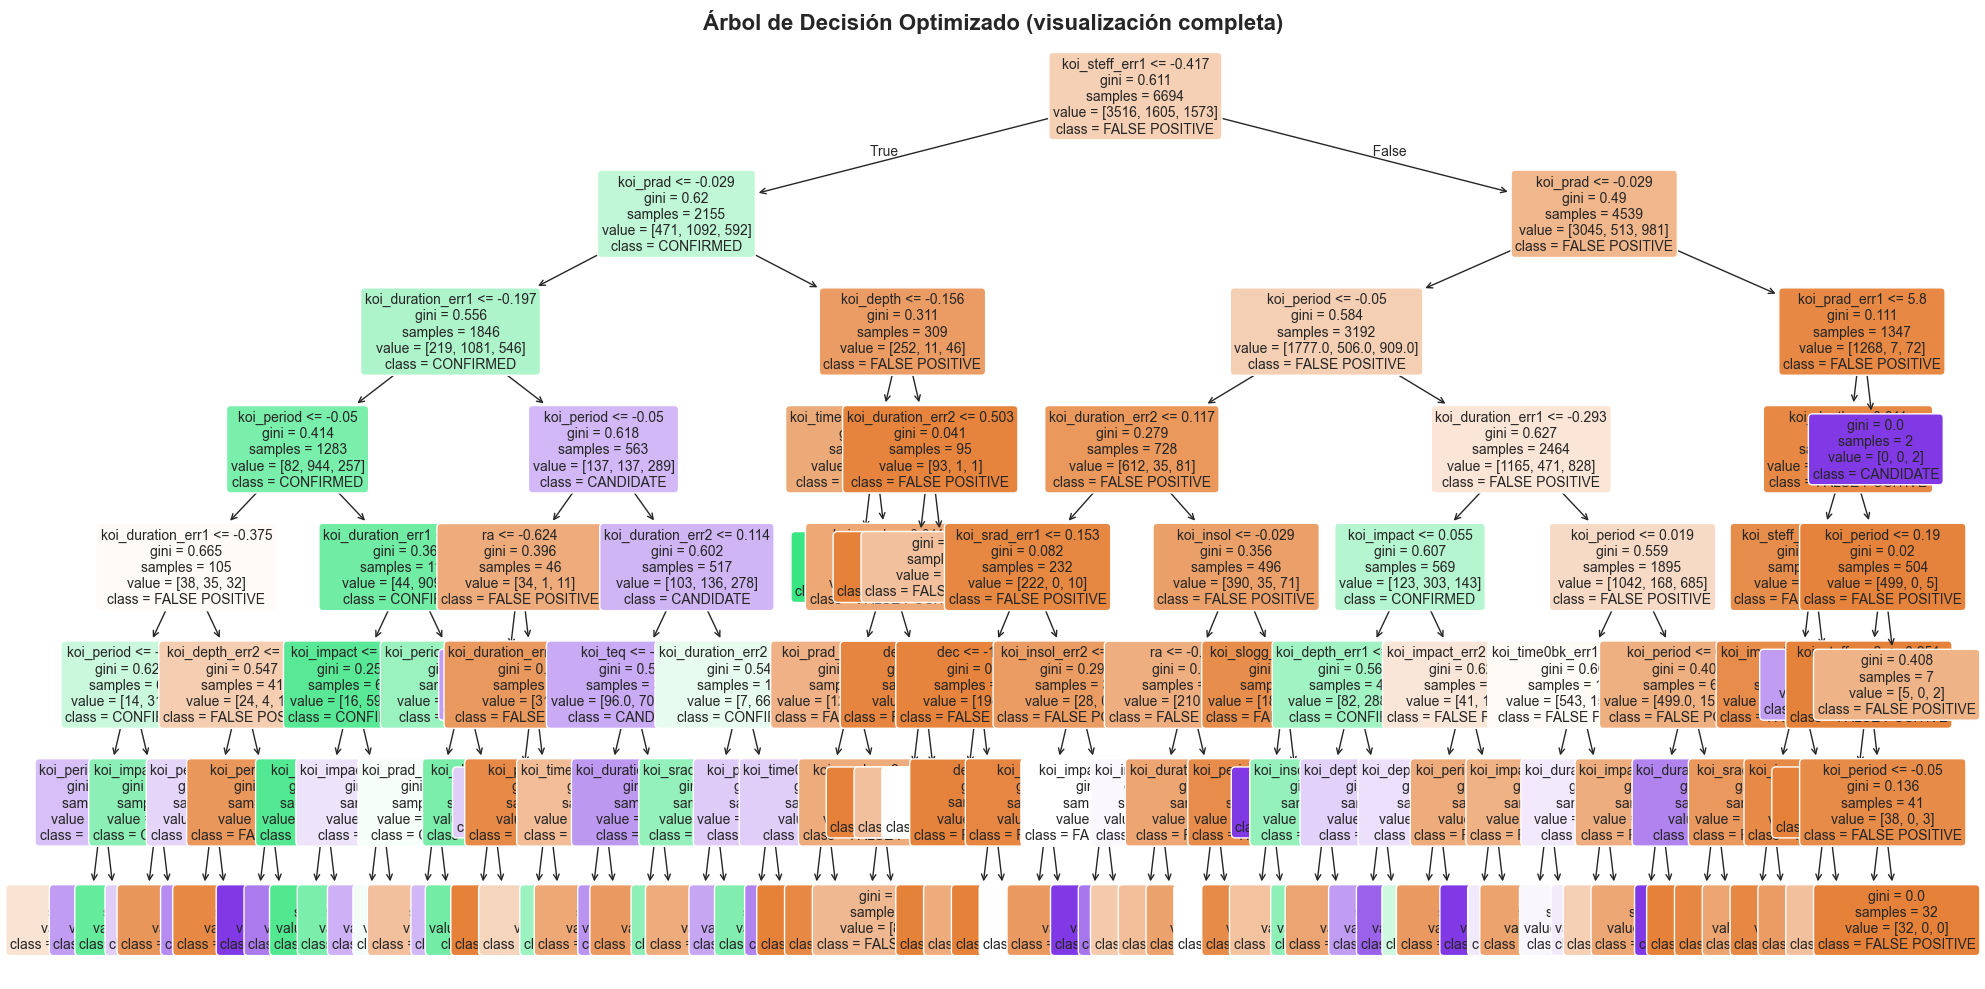

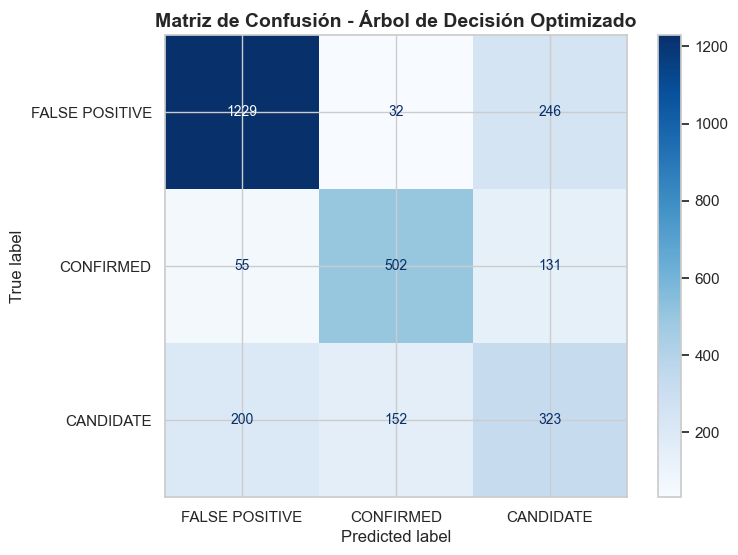


 RANDOM FOREST OPTIMIZADO
----------------------------------------
                precision    recall  f1-score   support

FALSE POSITIVE       0.81      0.92      0.86      1507
     CONFIRMED       0.76      0.78      0.77       688
     CANDIDATE       0.56      0.37      0.45       675

      accuracy                           0.76      2870
     macro avg       0.71      0.69      0.69      2870
  weighted avg       0.74      0.76      0.74      2870



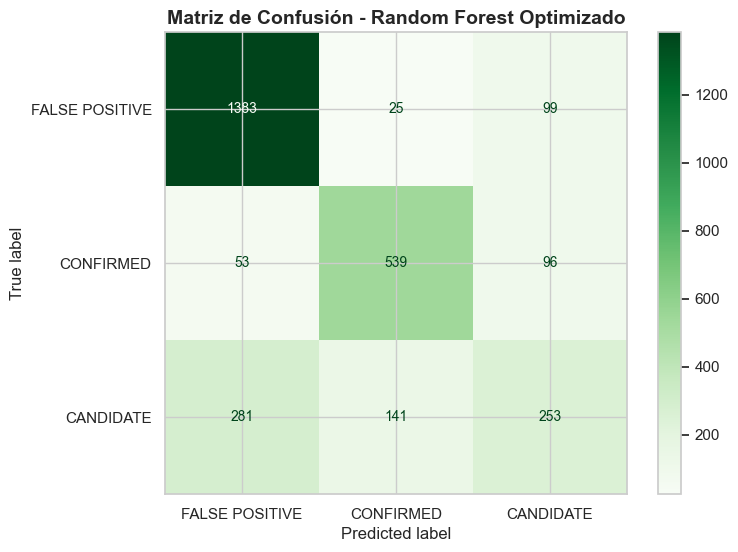


 LOGISTIC REGRESSION
----------------------------------------
                precision    recall  f1-score   support

FALSE POSITIVE       0.74      0.90      0.81      1507
     CONFIRMED       0.68      0.78      0.73       688
     CANDIDATE       0.47      0.17      0.25       675

      accuracy                           0.70      2870
     macro avg       0.63      0.62      0.60      2870
  weighted avg       0.66      0.70      0.66      2870



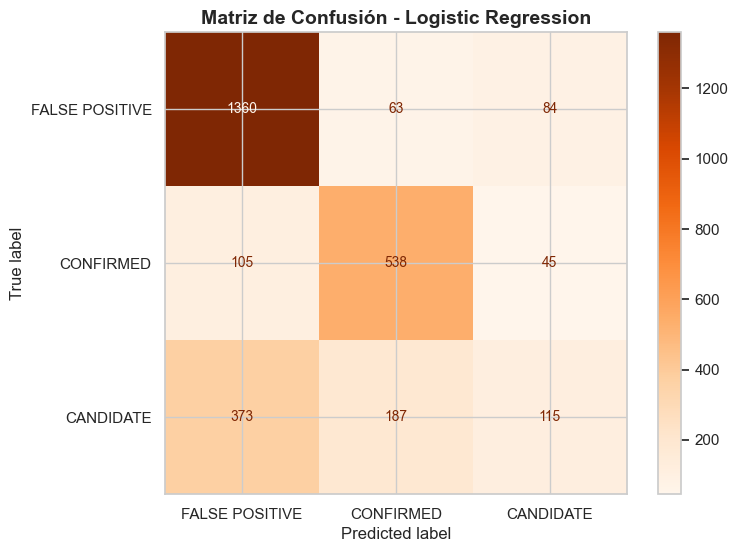


 Análisis de Importancia de Características


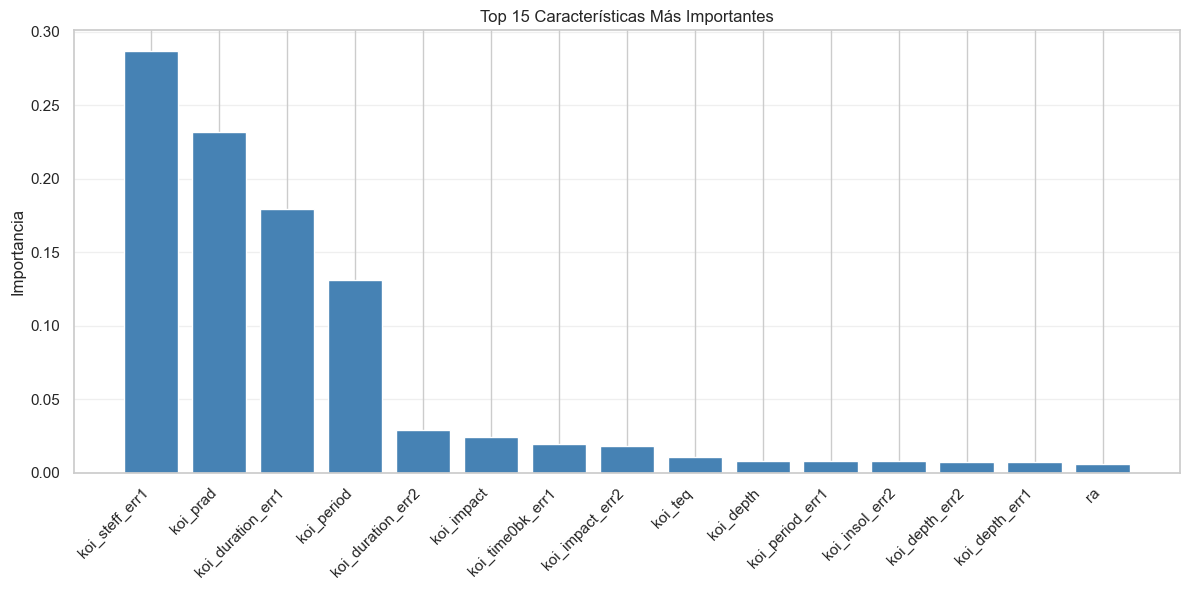


Top 10 características más importantes (Decision Tree):
          Feature  Importance
   koi_steff_err1    0.286596
         koi_prad    0.231966
koi_duration_err1    0.179743
       koi_period    0.131185
koi_duration_err2    0.028859
       koi_impact    0.024093
 koi_time0bk_err1    0.019565
  koi_impact_err2    0.017961
          koi_teq    0.010730
        koi_depth    0.008010


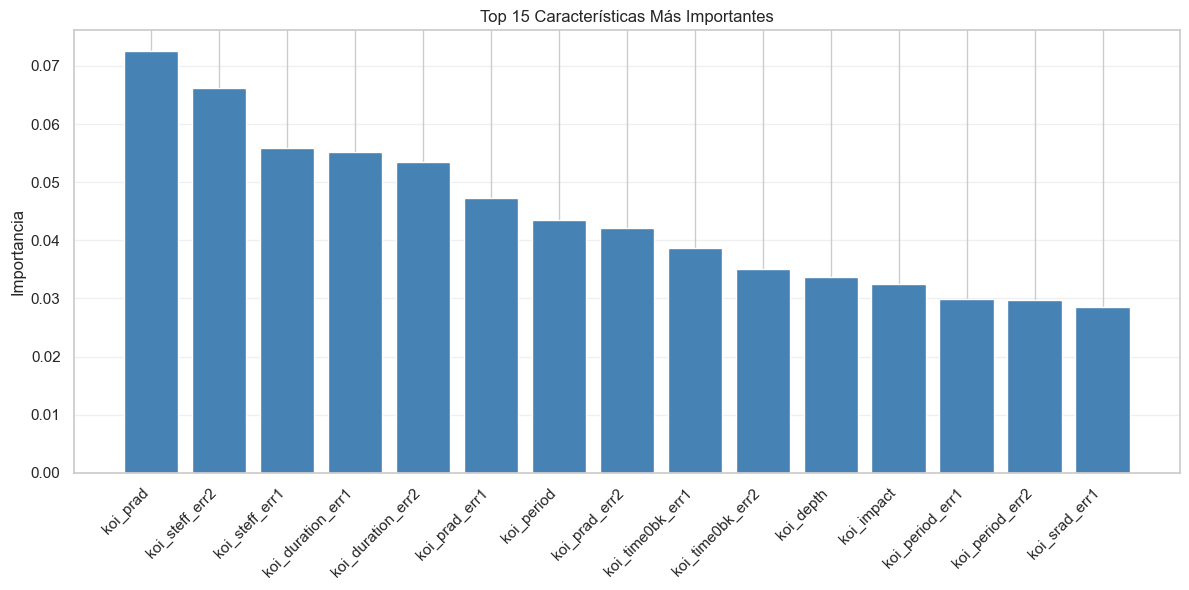


Top 10 características más importantes (Random Forest):
          Feature  Importance
         koi_prad    0.072486
   koi_steff_err2    0.066207
   koi_steff_err1    0.055907
koi_duration_err1    0.055131
koi_duration_err2    0.053545
    koi_prad_err1    0.047223
       koi_period    0.043426
    koi_prad_err2    0.042051
 koi_time0bk_err1    0.038750
 koi_time0bk_err2    0.035072


In [71]:
# 7. ANÁLISIS DETALLADO DE MODELOS PRINCIPALES (DT y RF)
# =============================================================================
print_section("ANÁLISIS DETALLADO: ÁRBOLES DE DECISIÓN Y RANDOM FOREST")

# 7.1 Análisis del Árbol de Decisión
print("\n ÁRBOL DE DECISIÓN OPTIMIZADO")
print("-" * 40)
dt_pred = detailed_results["Decision Tree (Optimizado)"]['y_pred']
dt_report = classification_report(y_test, dt_pred, target_names=target_names, output_dict=True)
print(classification_report(y_test, dt_pred, target_names=target_names))

# Visualizar el árbol (primeros niveles — si quieres limitar niveles, se puede podar el modelo antes)
plt.figure(figsize=(20, 10))
plot_tree(best_dt,
          feature_names=selected_features,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión Optimizado (visualización completa)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Matriz de confusión para DT
cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_dt.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Árbol de Decisión Optimizado', fontsize=14, fontweight='bold')
plt.show()

# 7.2 Análisis del Random Forest
print("\n RANDOM FOREST OPTIMIZADO")
print("-" * 40)
rf_pred = detailed_results["Random Forest (Optimizado)"]['y_pred']
rf_report = classification_report(y_test, rf_pred, target_names=target_names, output_dict=True)
print(classification_report(y_test, rf_pred, target_names=target_names))

# Matriz de confusión para RF
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Matriz de Confusión - Random Forest Optimizado', fontsize=14, fontweight='bold')
plt.show()
# 7.3 Análisis de Logistic Regression
print("\n LOGISTIC REGRESSION")
print("-" * 40)

# Predicciones del modelo
lr_pred = detailed_results["Logistic Regression"]['y_pred']

# Reporte de clasificación
lr_report = classification_report(
    y_test, lr_pred, target_names=target_names, output_dict=True
)
print(classification_report(y_test, lr_pred, target_names=target_names))

# Matriz de confusión para Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_lr.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title('Matriz de Confusión - Logistic Regression', fontsize=14, fontweight='bold')
plt.show()
# Importancia de características
print("\n Análisis de Importancia de Características")
dt_importance = feature_importance_analysis(best_dt, selected_features, top_n=15)
if dt_importance is not None:
    print("\nTop 10 características más importantes (Decision Tree):")
    print(dt_importance.head(10).to_string(index=False))

rf_importance = feature_importance_analysis(best_rf, selected_features, top_n=15)
if rf_importance is not None:
    print("\nTop 10 características más importantes (Random Forest):")
    print(rf_importance.head(10).to_string(index=False))



 ANÁLISIS DE CURVAS DE APRENDIZAJE

 Generando curvas de aprendizaje para detectar overfitting/underfitting...


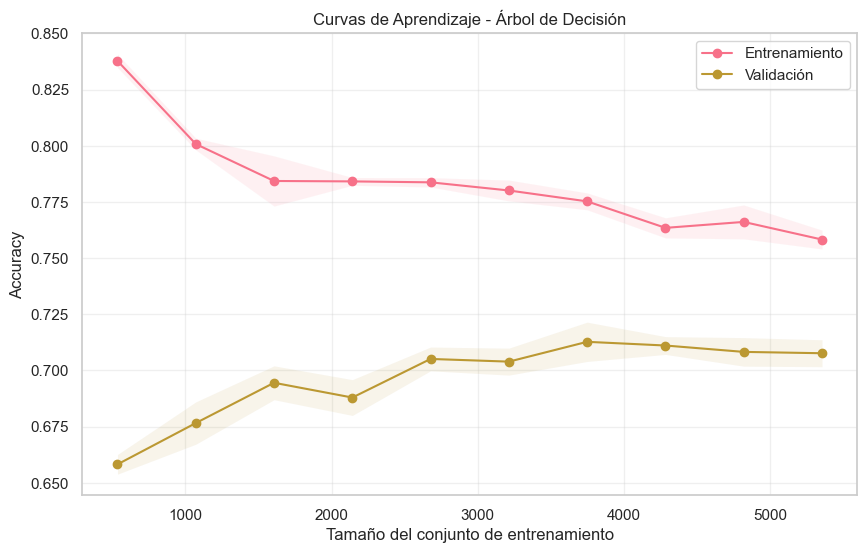

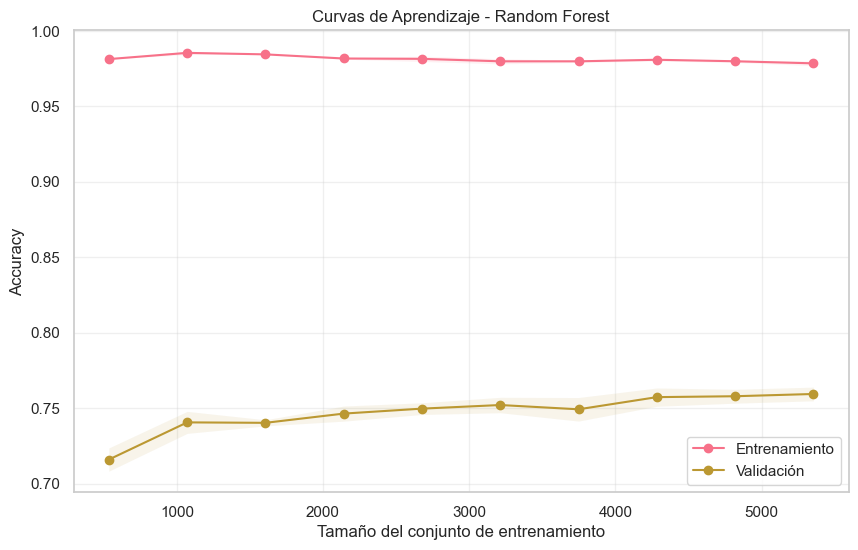

In [72]:
# =============================================================================
# 8. CURVAS DE APRENDIZAJE
# =============================================================================
print_section("ANÁLISIS DE CURVAS DE APRENDIZAJE")

print("\n Generando curvas de aprendizaje para detectar overfitting/underfitting...")
plot_learning_curves(best_dt, X_train_processed, y_train,
                    title="Curvas de Aprendizaje - Árbol de Decisión")
plot_learning_curves(best_rf, X_train_processed, y_train,
                    title="Curvas de Aprendizaje - Random Forest")



 INTERPRETACIÓN DEL MODELO CON SHAP

 Generando explicaciones SHAP para Random Forest...


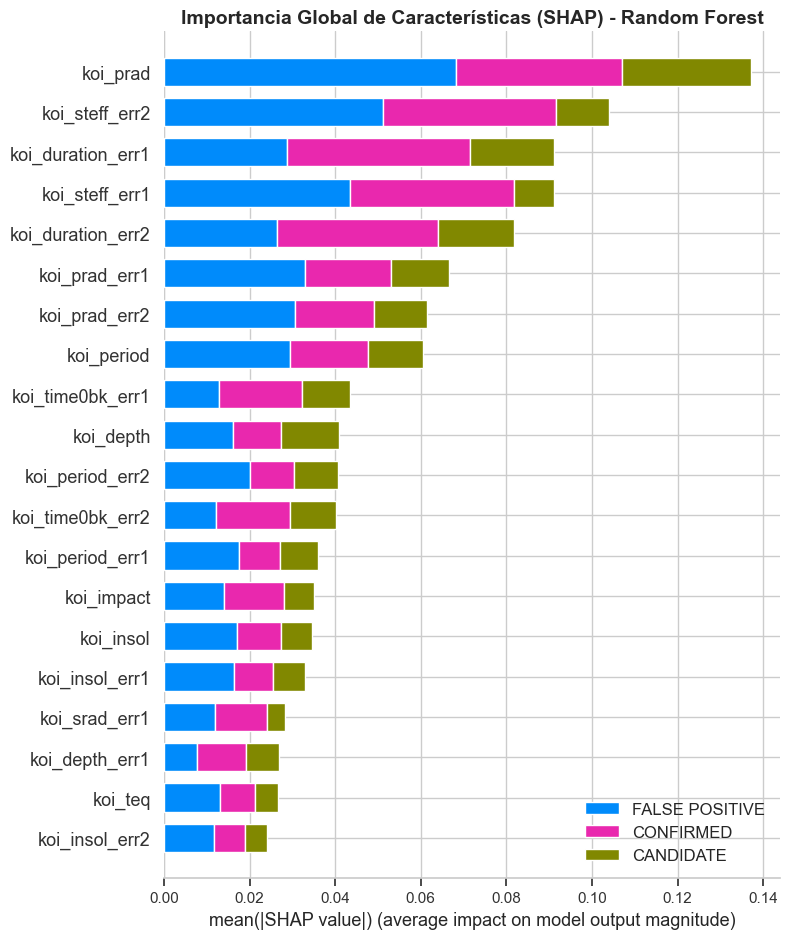

<Figure size 1200x800 with 0 Axes>

In [73]:
# =============================================================================
# 9. INTERPRETACIÓN CON SHAP (si está instalado)
# =============================================================================
print_section("INTERPRETACIÓN DEL MODELO CON SHAP")

try:
    import shap
    print("\n Generando explicaciones SHAP para Random Forest...")

    # Usar una muestra para SHAP (para eficiencia)
    sample_size = min(100, X_test_processed.shape[0])
    X_test_sample = X_test_processed[:sample_size]

    # Crear explicador SHAP
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_test_sample)

    # Crear DataFrame con nombres de características
    X_test_df = pd.DataFrame(X_test_sample, columns=selected_features)

    # Gráfico de importancia global
    plt.figure(figsize=(12, 8))
    # Para multiclass shap_values es lista; summary_plot maneja lista
    shap.summary_plot(shap_values, X_test_df, plot_type="bar", class_names=target_names, show=False)
    plt.title('Importancia Global de Características (SHAP) - Random Forest',
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Gráfico detallado para clase CONFIRMED (índice 1)
    try:
        idx_confirmed = 1
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values[idx_confirmed], X_test_df, show=False)
        plt.title('Impacto de Características en Predicción de CONFIRMED - Random Forest',
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception:
        # si shap_values no es lista o no soporta indexación, lo ignoramos
        pass

except Exception as e:
    print(f" SHAP no está disponible o falló: {e}")

In [74]:
# =============================================================================
# 10. CONCLUSIONES Y RECOMENDACIONES
# =============================================================================
print_section("CONCLUSIONES DEL ANÁLISIS")

best_model_name = results_df.iloc[0]['Modelo']
best_accuracy = results_df.iloc[0]['Accuracy (Test)']
best_f1 = results_df.iloc[0]['F1-Score (Weighted)']

# Lectura segura de métricas DT/RF del DataFrame de resultados (por si no aparecen)
def safe_metric(model_name, metric):
    try:
        return results_df[results_df['Modelo'] == model_name][metric].values[0]
    except Exception:
        return np.nan

dt_acc = safe_metric('Decision Tree (Optimizado)', 'Accuracy (Test)')
dt_f1 = safe_metric('Decision Tree (Optimizado)', 'F1-Score (Weighted)')
rf_acc = safe_metric('Random Forest (Optimizado)', 'Accuracy (Test)')
rf_f1 = safe_metric('Random Forest (Optimizado)', 'F1-Score (Weighted)')

top_rf_features = rf_importance.head(5)['Feature'].tolist() if (rf_importance is not None) else []

print(f"""
 RESUMEN EJECUTIVO:
{'='*60}

1. MEJOR MODELO: {best_model_name}
   - Accuracy: {best_accuracy:.4f}
   - F1-Score: {best_f1:.4f}

2. COMPARACIÓN DE TÉCNICAS PRINCIPALES:

   Árbol de Decisión (Optimizado):
   - Accuracy: {dt_acc:.4f}
   - F1-Score: {dt_f1:.4f}
   - Ventajas: Interpretable, rápido, reglas claras
   - Desventajas: Propenso a overfitting, menos robusto

   Random Forest (Optimizado):
   - Accuracy: {rf_acc:.4f}
   - F1-Score: {rf_f1:.4f}
   - Ventajas: Mayor precisión, robusto, menos overfitting
   - Desventajas: Menos interpretable, más costoso computacionalmente

3. CARACTERÍSTICAS MÁS IMPORTANTES:
   Las variables físicas más relevantes para la clasificación son:
   {', '.join(top_rf_features) if top_rf_features else 'No disponible'}

4. RENDIMIENTO POR CLASE:
""")

# Imprimir precisión por clase si rf_report existe
if 'rf_report' in locals() and isinstance(rf_report, dict):
    for cls in ['FALSE POSITIVE', 'CONFIRMED', 'CANDIDATE']:
        try:
            prec = rf_report[cls]['precision']
            print(f"   - {cls}: Precisión {prec:.2%}")
        except Exception:
            print(f"   - {cls}: Precisión (no disponible)")
else:
    print("   No hay reporte de clasificación de Random Forest disponible.")

print("""
5. RECOMENDACIONES:
   ✓ Random Forest muestra buen rendimiento general (según métricas).
   ✓ Se recomienda validar con más folds y/o otras métricas por clase.
   ✓ Considerar pipelines de balanceo si hay desbalance importante.
   ✓ Guardar el pipeline y el modelo optimizado para producción.
""")

# Guardar resultados
print("\n Guardando resultados...")
results_df.to_csv('resultados_modelos_kepler.csv', index=False)
print("✓ Resultados guardados en 'resultados_modelos_kepler.csv'")






 CONCLUSIONES DEL ANÁLISIS

 RESUMEN EJECUTIVO:

1. MEJOR MODELO: XGBoost
   - Accuracy: 0.7613
   - F1-Score: 0.7516

2. COMPARACIÓN DE TÉCNICAS PRINCIPALES:

   Árbol de Decisión (Optimizado):
   - Accuracy: 0.7157
   - F1-Score: 0.7172
   - Ventajas: Interpretable, rápido, reglas claras
   - Desventajas: Propenso a overfitting, menos robusto

   Random Forest (Optimizado):
   - Accuracy: 0.7578
   - F1-Score: 0.7420
   - Ventajas: Mayor precisión, robusto, menos overfitting
   - Desventajas: Menos interpretable, más costoso computacionalmente

3. CARACTERÍSTICAS MÁS IMPORTANTES:
   Las variables físicas más relevantes para la clasificación son:
   koi_prad, koi_steff_err2, koi_steff_err1, koi_duration_err1, koi_duration_err2

4. RENDIMIENTO POR CLASE:

   - FALSE POSITIVE: Precisión 80.55%
   - CONFIRMED: Precisión 76.45%
   - CANDIDATE: Precisión 56.47%

5. RECOMENDACIONES:
   ✓ Random Forest muestra buen rendimiento general (según métricas).
   ✓ Se recomienda validar con más fol

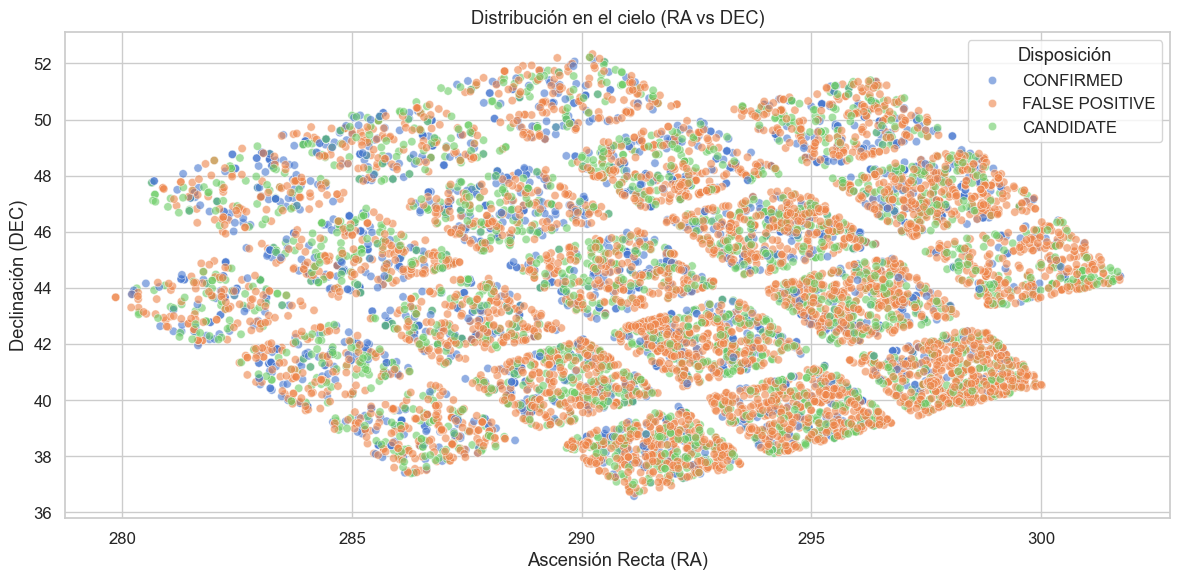

In [75]:


# Cargar los datos
df = pd.read_csv("cumulative (2).csv")

# Estilo
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)




# -------- 6. Mapa celeste (RA vs DEC) --------
plt.figure()
sns.scatterplot(data=df, x='ra', y='dec', hue='koi_disposition', alpha=0.6)
plt.title('Distribución en el cielo (RA vs DEC)')
plt.xlabel('Ascensión Recta (RA)')
plt.ylabel('Declinación (DEC)')
plt.legend(title='Disposición')
plt.tight_layout()
plt.show()
